In [105]:
setwd("~/Projects/R/ISLR2")

In [106]:
getwd()

[1] "/Users/rob/Projects/R/ISLR2"

In [107]:
source("InstallAndLoadScripts/loadlibraries.R")

In [108]:
loadISLR2Libraries()

In [109]:
getwd()

[1] "/Users/rob/Projects/R/ISLR2"

In [110]:
options(repr.plot.width = 15, repr.plot.height = 12)

In [111]:
Greenhouses = read.csv("data/GreenhousesValidation.csv")

In [112]:
as_tibble(Greenhouses)[1:10,]

price,solarPanels,greenhouses,size,rowIndex,price.1
<int>,<dbl>,<dbl>,<int>,<int>,<dbl>
2950,20,2.00,460,2,2973.8556
1150,12,1.50,340,5,928.7348
1700,16,2.00,300,6,1530.4639
1400,6,4.25,235,29,1256.9913
3950,14,2.00,680,30,3461.6787
3950,12,4.25,680,33,4604.3543
2500,24,2.00,515,39,3811.6916
1500,7,3.00,290,41,924.9051
5950,28,3.00,685,42,5936.3090


In [113]:
y = -3529.3633 + 130.16*Greenhouses$solarPanels + 623.554*Greenhouses$greenhouses + 5.7672*Greenhouses$size

In [114]:
print(y[1:10])

 [1] 2973.8567  928.7357 1530.4647 1256.9932 3461.6807 4604.3572 3811.6927
 [8]  924.9067 5936.3107  814.9837


In [115]:
summary(Greenhouses)

     price        solarPanels     greenhouses         size       
 Min.   :  750   Min.   : 4.00   Min.   :1.000   Min.   : 210.0  
 1st Qu.: 1950   1st Qu.:10.00   1st Qu.:2.000   1st Qu.: 407.5  
 Median : 2750   Median :14.00   Median :3.000   Median : 532.5  
 Mean   : 3624   Mean   :15.31   Mean   :3.141   Mean   : 547.1  
 3rd Qu.: 3950   3rd Qu.:20.00   3rd Qu.:4.000   3rd Qu.: 667.5  
 Max.   :28500   Max.   :40.00   Max.   :8.000   Max.   :1405.0  
    rowIndex        price.1     
 Min.   :  2.0   Min.   :-1145  
 1st Qu.:113.5   1st Qu.: 1822  
 Median :212.5   Median : 3447  
 Mean   :206.9   Mean   : 3577  
 3rd Qu.:304.0   3rd Qu.: 4654  
 Max.   :390.0   Max.   :14768  

In [116]:
max(Greenhouses["price"] - Greenhouses["price.1"])

[1] 13731.62

In [117]:
RSS = sum((Greenhouses["price"] - Greenhouses["price.1"])^2)

In [118]:
print(RSS)

[1] 242107568


In [119]:
MSE = sqrt(RSS/76)

In [120]:
print(MSE)

[1] 1784.832


In [121]:
#cbPalette = c("#999999", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7")
#scale_colour_manual(values=cbPalette)

In [122]:
lm01 = lm(price ~ solarPanels + greenhouses + size, data=Greenhouses)
summary(lm01)


Call:
lm(formula = price ~ solarPanels + greenhouses + size, data = Greenhouses)

Residuals:
    Min      1Q  Median      3Q     Max 
-1922.6  -933.3  -314.0   590.2 11337.6 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -4974.647    556.989  -8.931 1.81e-13 ***
solarPanels   152.776     32.107   4.758 9.10e-06 ***
greenhouses   782.628    152.634   5.127 2.17e-06 ***
size            6.950      1.389   5.004 3.53e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1694 on 76 degrees of freedom
Multiple R-squared:  0.7817,	Adjusted R-squared:  0.7731 
F-statistic:  90.7 on 3 and 76 DF,  p-value: < 2.2e-16


In [123]:
f1 = ggplot(Greenhouses, aes(x=greenhouses, y=price)) +
  geom_point(size=0.75, col="orange") +
  geom_smooth(method = "lm", col="blue") +
  ggtitle("price ~ greenhouses") +
  #xlim(0, 300) +
  scale_fill_hue(l=40)

In [124]:
f2 = ggplot(Greenhouses, aes(x=solarPanels, y=price)) +
  geom_point(size=0.75, col="orange") +
  geom_smooth(method = "lm", col="blue") +
  ggtitle("price ~ solarPanels") +
  #xlim(0, 300) +
  scale_fill_hue(l=40)

In [125]:
f3 = ggplot(Greenhouses, aes(x=size, y=price)) +
  geom_point(size=0.75, col="orange") +
  geom_smooth(method = "lm", col="blue") +
  ggtitle("price ~ size") +
  #xlim(0, 300) +
  scale_fill_hue(l=40)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


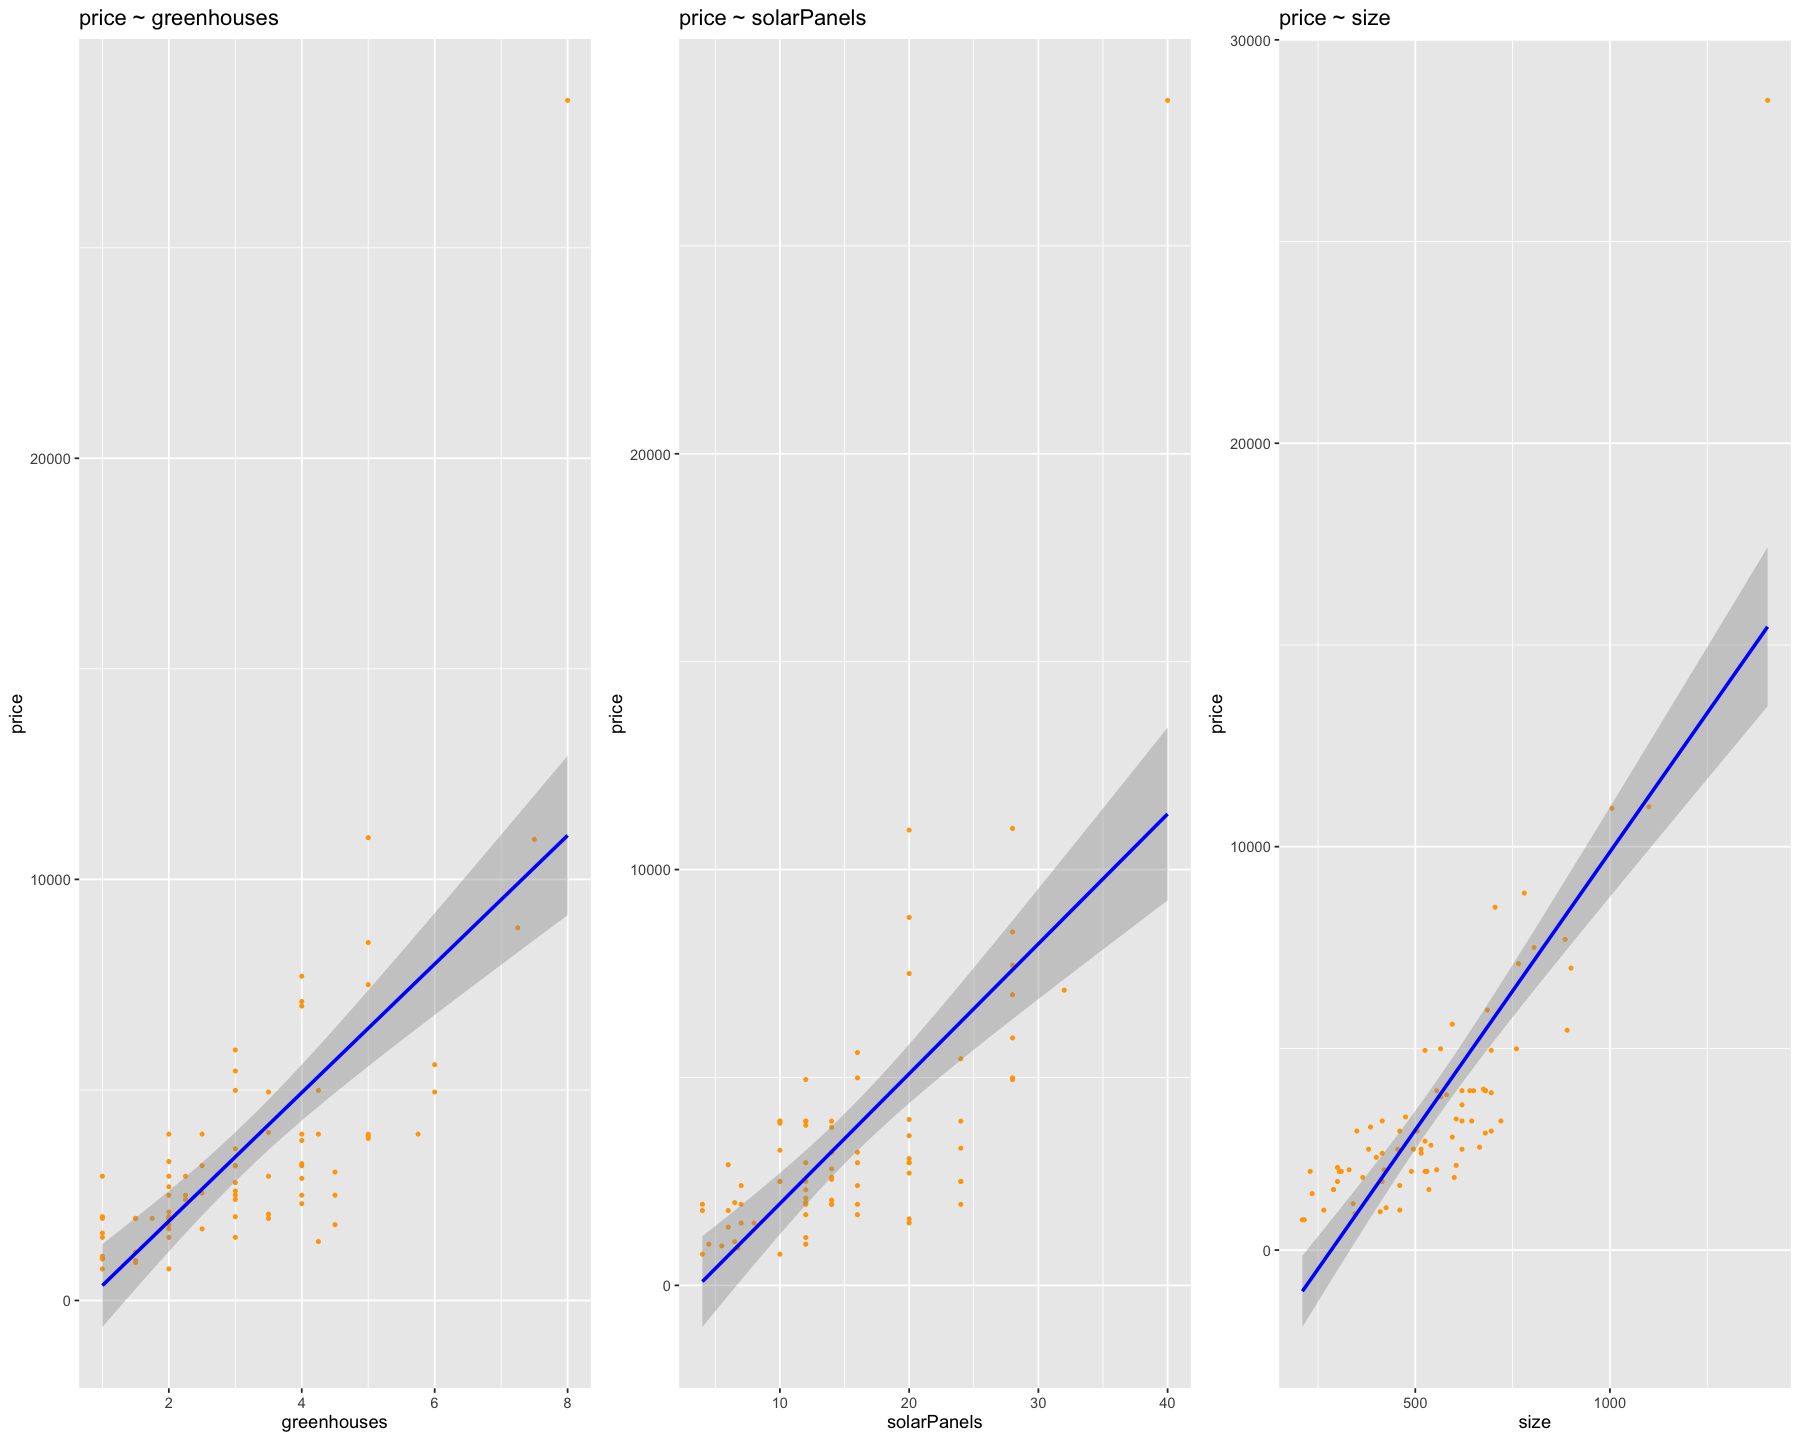

In [126]:
grid.arrange(f1, f2, f3, ncol = 3)

In [127]:
gh=3; sp=14; sz=530
x = seq(from=4, to=40, by=0.5)
newDf = data.frame(x = x, y = -3529.3633 + 130.16*x + 623.554*gh + 5.7672*sz)
#as_tibble(newDf)[1:10,]

`geom_smooth()` using formula = 'y ~ x'


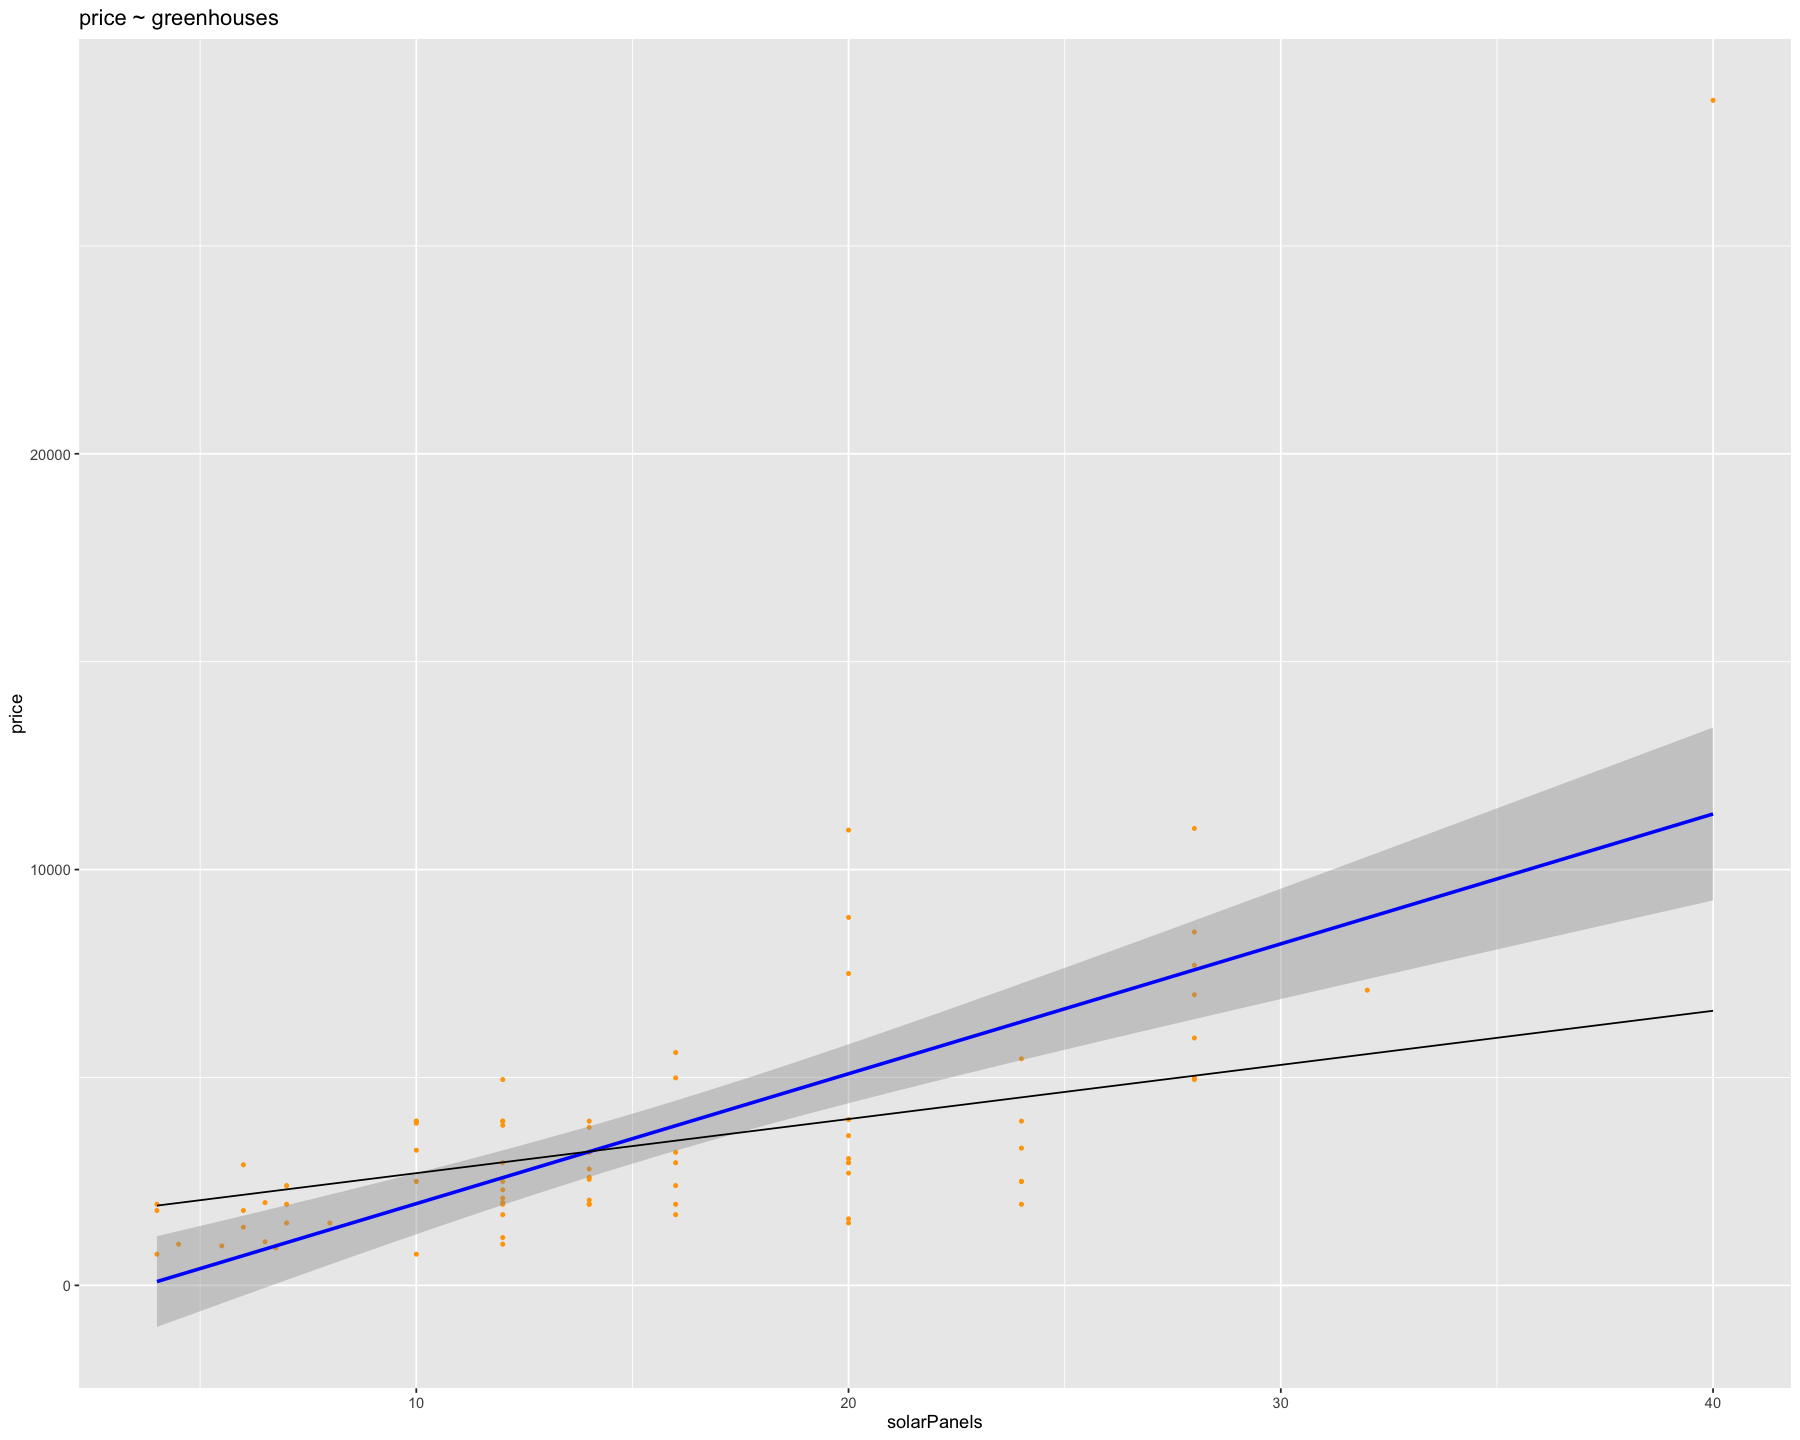

In [128]:
f4 = ggplot(Greenhouses, aes(x=solarPanels, y=price)) +
  geom_point(size=0.75, col="orange") +
  geom_smooth(method = "lm", col="blue") +
  geom_line(data=newDf, aes(x=x, y=y)) +
  ggtitle("price ~ greenhouses")
plot(f4)

In [129]:
names(lm01)

[1] "coefficients"  "residuals"     "effects"       "rank"         
 [5] "fitted.values" "assign"        "qr"            "df.residual"  
 [9] "xlevels"       "call"          "terms"         "model"

In [130]:
dim(Greenhouses)

[1] 80  6

In [131]:
residuals(lm01)[1:10]

1          2          3          4          5          6          7 
  106.7936   754.3360   579.9245   498.5331   494.4133  -960.9473 -1336.5697 
         8          9         10 
 1041.7828  -461.8302  1707.7501

In [132]:
RSS = sum(residuals(lm01)^2)

In [133]:
RSS

[1] 218091537

In [134]:
MSE = sqrt(RSS/76)

In [135]:
MSE

[1] 1693.997

In [136]:
mean_price = mean(Greenhouses$price)

In [137]:
mean_price

[1] 3624.375

In [138]:
TSS = sum((Greenhouses$price - mean_price)^2)

In [139]:
TSS

[1] 998915969

In [140]:
R2 = 1 - RSS/TSS

In [141]:
R2

[1] 0.7816718

In [142]:
cor(Greenhouses$price, predict(lm01))^2

[1] 0.7816718

In [143]:
p = 3

In [144]:
n = 80

In [145]:
R_adj = 1 - ((1 - R2) * (n - 1) / (n - p - 1))

In [146]:
R_adj

[1] 0.7730536

In [147]:
F_stat = ((TSS-RSS)/p)/(RSS/(n-p-1))

In [148]:
F_stat

[1] 90.69992

In [149]:
p_value = pf(F_stat, p, n-p-1, lower.tail=FALSE)

In [150]:
p_value

[1] 4.795449e-25

In [151]:
str_interp("RSS = ${RSS}, MSE = ${MSE}, R2 = ${R2}, R_adj = ${R_adj}, F = ${F_stat}, 
           p = ${p_value}")

[1] "RSS = 218091537.053565, MSE = 1693.99689714796, R2 = 0.781671788342241, R_adj = 0.773053569461014, F = 90.6999229324426, \n           p = 4.79544881609072e-25"

In [152]:
summary(lm01)


Call:
lm(formula = price ~ solarPanels + greenhouses + size, data = Greenhouses)

Residuals:
    Min      1Q  Median      3Q     Max 
-1922.6  -933.3  -314.0   590.2 11337.6 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -4974.647    556.989  -8.931 1.81e-13 ***
solarPanels   152.776     32.107   4.758 9.10e-06 ***
greenhouses   782.628    152.634   5.127 2.17e-06 ***
size            6.950      1.389   5.004 3.53e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1694 on 76 degrees of freedom
Multiple R-squared:  0.7817,	Adjusted R-squared:  0.7731 
F-statistic:  90.7 on 3 and 76 DF,  p-value: < 2.2e-16


In [153]:
Greenhouses$pred = predict(lm01)

In [154]:
as_tibble(Greenhouses)[1:15,]

price,solarPanels,greenhouses,size,rowIndex,price.1,pred
<int>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>
2950,20,2.00,460,2,2973.8556,2843.2064
1150,12,1.50,340,5,928.7348,395.6640
1700,16,2.00,300,6,1530.4639,1120.0755
1400,6,4.25,235,29,1256.9913,901.4669
3950,14,2.00,680,30,3461.6787,3455.5867
3950,12,4.25,680,33,4604.3543,4910.9473
2500,24,2.00,515,39,3811.6916,3836.5697
1500,7,3.00,290,41,924.9051,458.2172
5950,28,3.00,685,42,5936.3090,6411.8302


In [155]:
dim(Greenhouses)

[1] 80  7

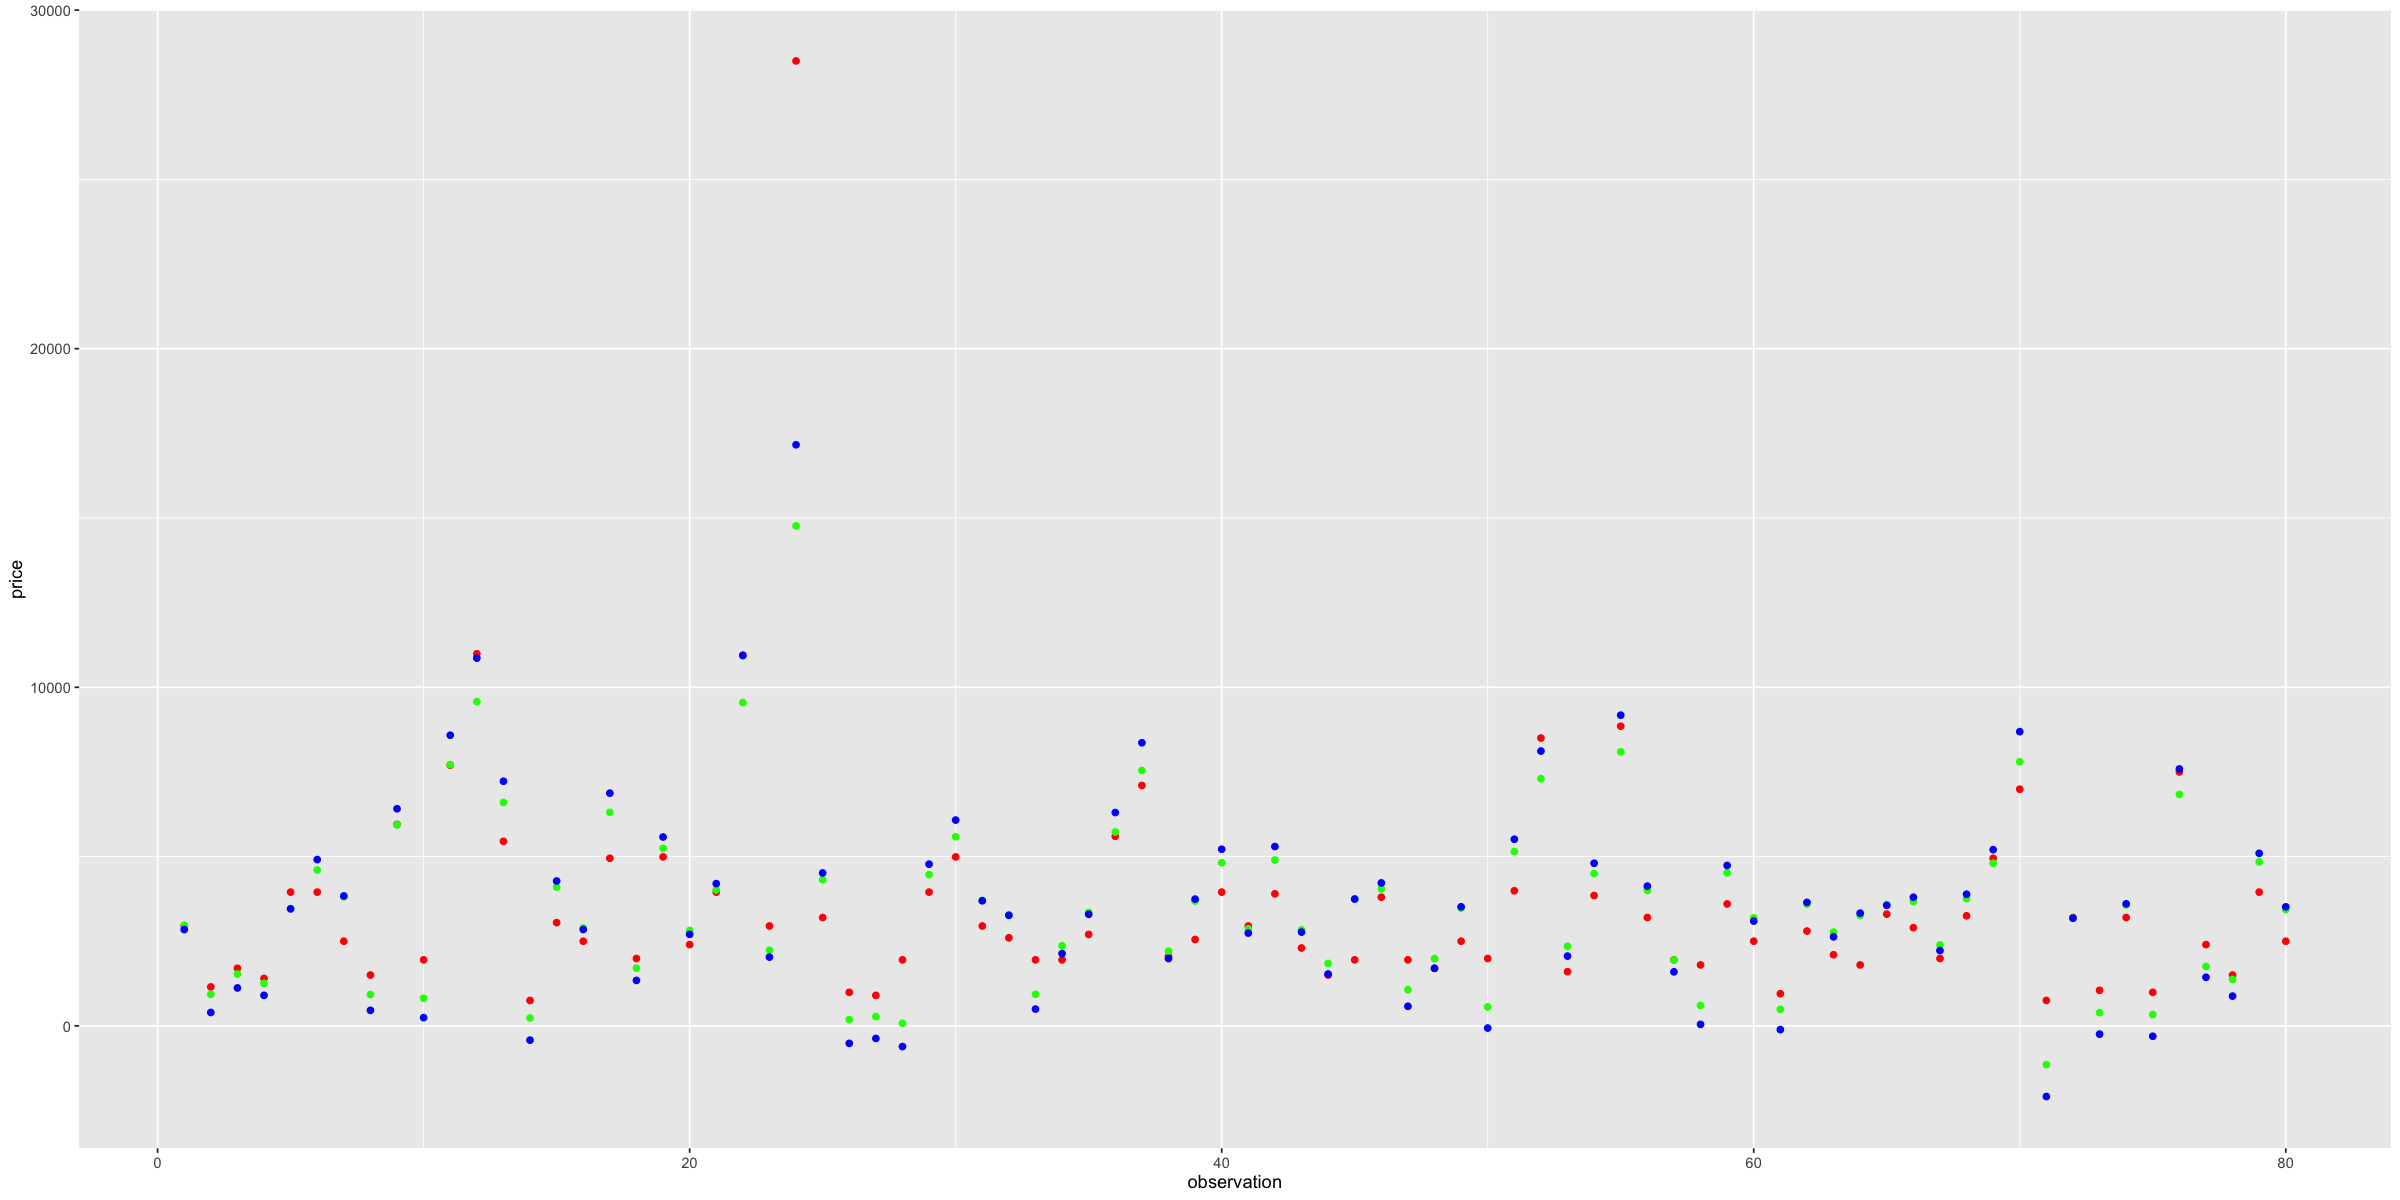

In [156]:
options(repr.plot.width = 20, repr.plot.height =10)
ggplot() + 
  geom_point(data = Greenhouses, aes(x=1:80, y = price), color = "red") +
  geom_point(data = Greenhouses, aes(x=1:80, y = price.1), color = "green") +
  geom_point(data = Greenhouses, aes(x=1:80, y = pred), color = "blue") +
  xlab('observation') + ylab('price')